##### (b)

In [320]:
import matplotlib.pyplot as plt
import numpy as np
import src.util as util

from src.linear_model import LinearModel

In [321]:
x_train, y_train = util.load_dataset('data/ds5_train.csv', add_intercept=True)
x_valid, y_valid = util.load_dataset('data/ds5_valid.csv', add_intercept=True)
x_test, y_test = util.load_dataset('data/ds5_test.csv', add_intercept=True)
print(x_train.shape, x_train)

(300, 2) [[ 1.         -4.02975001]
 [ 1.         -2.52457661]
 [ 1.          2.7946174 ]
 [ 1.          1.69590357]
 [ 1.         -1.45839187]
 [ 1.          0.8368018 ]
 [ 1.          4.04012671]
 [ 1.          1.94672233]
 [ 1.         -2.57638118]
 [ 1.          1.69435277]
 [ 1.          4.55563078]
 [ 1.         -1.57818748]
 [ 1.          3.57525896]
 [ 1.          4.31427256]
 [ 1.         -3.87303135]
 [ 1.          2.64900274]
 [ 1.          2.15802899]
 [ 1.          4.00870375]
 [ 1.         -1.12401711]
 [ 1.          4.15225061]
 [ 1.         -2.16654758]
 [ 1.         -4.41524444]
 [ 1.         -0.69531647]
 [ 1.         -3.77755514]
 [ 1.         -2.39641247]
 [ 1.         -2.16684545]
 [ 1.         -2.58082722]
 [ 1.         -1.20611524]
 [ 1.          1.27583294]
 [ 1.         -3.04415956]
 [ 1.          1.0424325 ]
 [ 1.          4.12796076]
 [ 1.         -4.46018687]
 [ 1.          2.8905592 ]
 [ 1.          2.45490456]
 [ 1.         -4.7127504 ]
 [ 1.          0.51

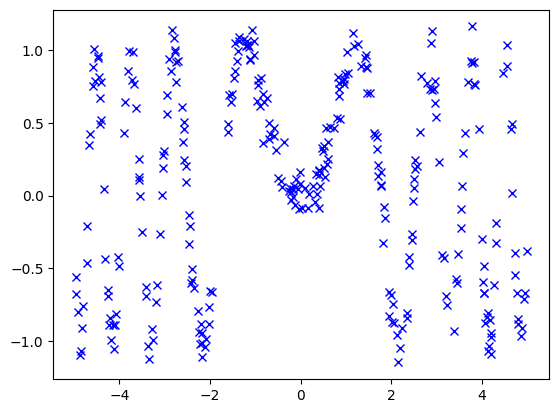

In [322]:
plt.plot(x_train[:, -1], y_train, 'bx', linewidth=2)

In [323]:
   # *** START CODE HERE ***
    # Fit a LWR model
    # Get MSE value on the validation set
    # Plot validation predictions on top of training set
    # No need to save predictions
    # Plot data
    # *** END CODE HERE ***

In [324]:
class LocallyWeightedLinearRegression(LinearModel):
    """Locally Weighted Regression (LWR).

    Example usage:
        > clf = LocallyWeightedLinearRegression(tau)
        > clf.fit(x_train, y_train)
        > clf.predict(x_eval)
    """

    def __init__(self, tau):
        super(LocallyWeightedLinearRegression, self).__init__()
        self.tau = tau
        self.x = None
        self.y = None

    def fit(self, x, y):
        """Fit LWR by saving the training set.

        """
        # *** START CODE HERE ***
        self.x = x
        self.y = y
        # *** END CODE HERE ***

    def predict(self, x):
        """Make predictions given inputs x.

        Args:
            x: Inputs of shape (m, n).

        Returns:
            Outputs of shape (m,).
        """
        # *** START CODE HERE ***
        
        m, n = x.shape
        preds = np.zeros(m)
        
        for i in range(m):
            query = x[i] # (n, )
            diff = self.x - query # (m_train, n)
            w = np.exp(-np.sum(diff**2, axis=1) / (2 * self.tau**2)) # (m_train, )
            
            b = self.x.T @ (w[:, None] * self.x) # doing * to do fast diagonalization
            a = np.linalg.inv(b)
            theta = a @ self.x.T @ (w * self.y) # (n, )
            
            
            preds[i] = np.dot(theta, query)
        
        return preds        
        # *** END CODE HERE ***

In [325]:
lwr = LocallyWeightedLinearRegression(0.05)
lwr.fit(x_train, y_train)


In [326]:
def plot(x, y_label, y_pred, title):
    plt.figure()
    plt.plot(x[:, -1], y_label, 'bx', linewidth=2, label='label')
    plt.plot(x[:, -1], y_pred, 'ro', linewidth=2, label='prediction')
    plt.suptitle(title, fontsize=12)
    plt.legend(loc='upper left')

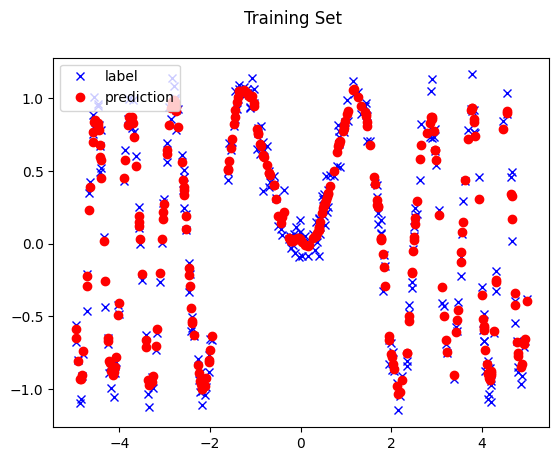

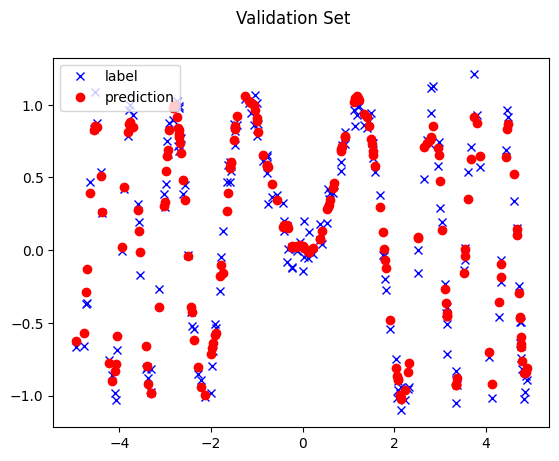

In [327]:
y_train_pred = lwr.predict(x_train)
plot(x_train, y_train, y_train_pred, "Training Set")

y_valid_pred = lwr.predict(x_valid)
plot(x_valid, y_valid, y_valid_pred, "Validation Set")

##### (c)

In [328]:
# *** START CODE HERE ***
    # Search tau_values for the best tau (lowest MSE on the validation set)
    # Fit a LWR model with the best tau value
    # Run on the test set to get the MSE value
    # Save predictions to pred_path
    # Plot data
    # *** END CODE HERE ***
tau_values=[3e-2, 5e-2, 1e-1, 5e-1, 1e0, 1e1]

In [337]:
mse_best = np.inf
tau_best = 0

for tau in tau_values:
    lwr = LocallyWeightedLinearRegression(tau)
    lwr.fit(x_train, y_train)
    y_valid_pred = lwr.predict(x_valid)
    
    mse = np.mean((y_valid_pred - y_valid)**2)
    print(tau, mse)
    if mse < mse_best:
        tau_best = tau
        mse_best = mse
        
print(f"best tau: {tau_best}, best mse: {mse_best}")

0.03 0.018096163124052156
0.05 0.01240007615048295
0.1 0.024224589379805154
0.5 0.33053126821375256
1.0 0.4000959480180862
10.0 0.4337439227232362
best tau: 0.05, best mse: 0.01240007615048295


0.016990143386868863


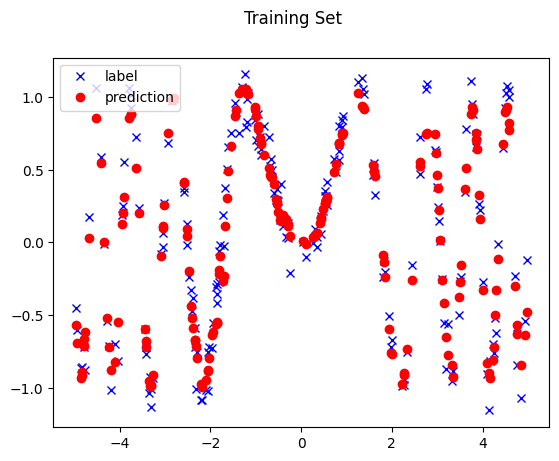

In [331]:
lwr = LocallyWeightedLinearRegression(0.05)
lwr.fit(x_train, y_train)

y_test_pred = lwr.predict(x_test)
plot(x_test, y_test, y_test_pred, "Training Set")
print(np.mean((y_test_pred - y_test)**2))
